In [1]:
import torch
import sys
from pathlib import Path

from src.model import ImageTransformPlagiarismPredictor
from src.dataset import ImageTransformer, TransformTokenizer, TRANSFORM_TOKENS
from PIL import Image
from omegaconf import OmegaConf
from torchvision import transforms
import os

%load_ext autoreload
%autoreload 2

In [2]:
# !pip install efficientnet-pytorch
# !pip install numpy==1.23.5

In [3]:
config = OmegaConf.load('configs/train_config_plagiarism.yaml')

model = ImageTransformPlagiarismPredictor(config.model)

# checkpoint_path = "/mnt/DATA2/dorin/Image-Transform-Predict/checkpoints/itp_plagiarism_pretrain/checkpoint_epoch_17.pth"
checkpoint_path = "/mnt/DATA2/dorin/Image-Transform-Predict/checkpoints/itp_plagiarism_tune/checkpoint_epoch_14.pth"

checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.to('cpu')
model.eval()
print('ready')

Loaded pretrained weights for efficientnet-b3
ready


```
python export_plagiarism_weights.py \
    --checkpoint /mnt/DATA2/dorin/Image-Transform-Predict/checkpoints/itp_plagiarism_tune/checkpoint_epoch_14.pth \
    --output_dir /mnt/DATA2/dorin/weights/transformpredictor/effnet_updated/ \
    --verify
```

In [4]:
# torch.save(checkpoint['model_state_dict'], '/mnt/DATA2/dorin/Image-Transform-Predict/checkpoints/itp_plagiarism_pretrain/model_weights.pth')

In [6]:
preprocess = transforms.Compose([
            transforms.Resize((300, 300)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

['grayscale', 'rotate_180', 'crop']


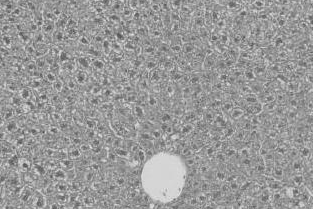

In [20]:
image_path_1 = '/mnt/DATA2/dorin/imgs/bio_from_prod/image_7.jpg'
image_path_2 = '/mnt/DATA2/dorin/imgs/bio_from_prod/image_10.jpg'
# image_path_1 = "/mnt/DATA2/dorin/imgs/bio_from_prod/image_12.jpg"
# image_path_2 = "/mnt/DATA2/dorin/imgs/bio_from_prod/image_10.jpg"

image_1 = Image.open(image_path_1)
image_2 = Image.open(image_path_2)

# image_1.show()
# image_2.show()

it = ImageTransformer()
transformed_image_1, sequence_1 = it.transform(image_1, p=0.3)
print(sequence_1)
transformed_image_1

In [22]:
image_tensor_1 = preprocess(image_1).unsqueeze(0)
image_tensor_2 = preprocess(image_2).unsqueeze(0)
transformed_image_tensor = preprocess(transformed_image_1).unsqueeze(0)

generated = model.generate(image_tensor_1, transformed_image_tensor, max_new_tokens=10, do_sample=False) #, top_k=3)

print(generated)

tokenizer = TransformTokenizer()
tokens = tokenizer.decode(generated[0][0], skip_special_tokens=True)
print(f"Predicted: {tokens}")
print(f"Target: {sequence_1}")

(tensor([[ 1,  4,  6, 10,  2,  0,  0,  0,  0,  0,  0]]), tensor([1.0000]))
Predicted: ['grayscale', 'rotate_180', 'crop']
Target: ['grayscale', 'rotate_180', 'crop']


In [23]:
logits = model(image_tensor_1, image_tensor_2, torch.tensor([[1]]))
logits = logits[0][0]
logits[:, model.pad_token_id] = -float('inf')
logits[:, model.bos_token_id] = -float('inf')
probs = torch.exp(logits) / torch.exp(logits).sum(dim=-1, keepdim=True)
p_eos = probs[:, 2]
similarities = 1.0 - p_eos
similarities.item()

0.00037592649459838867

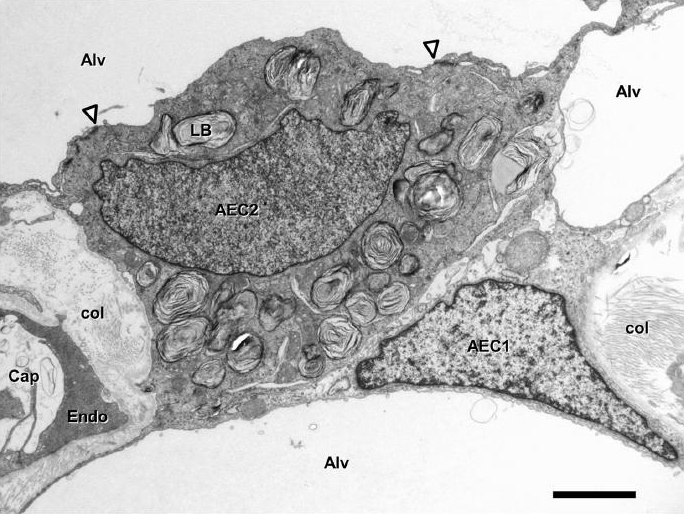

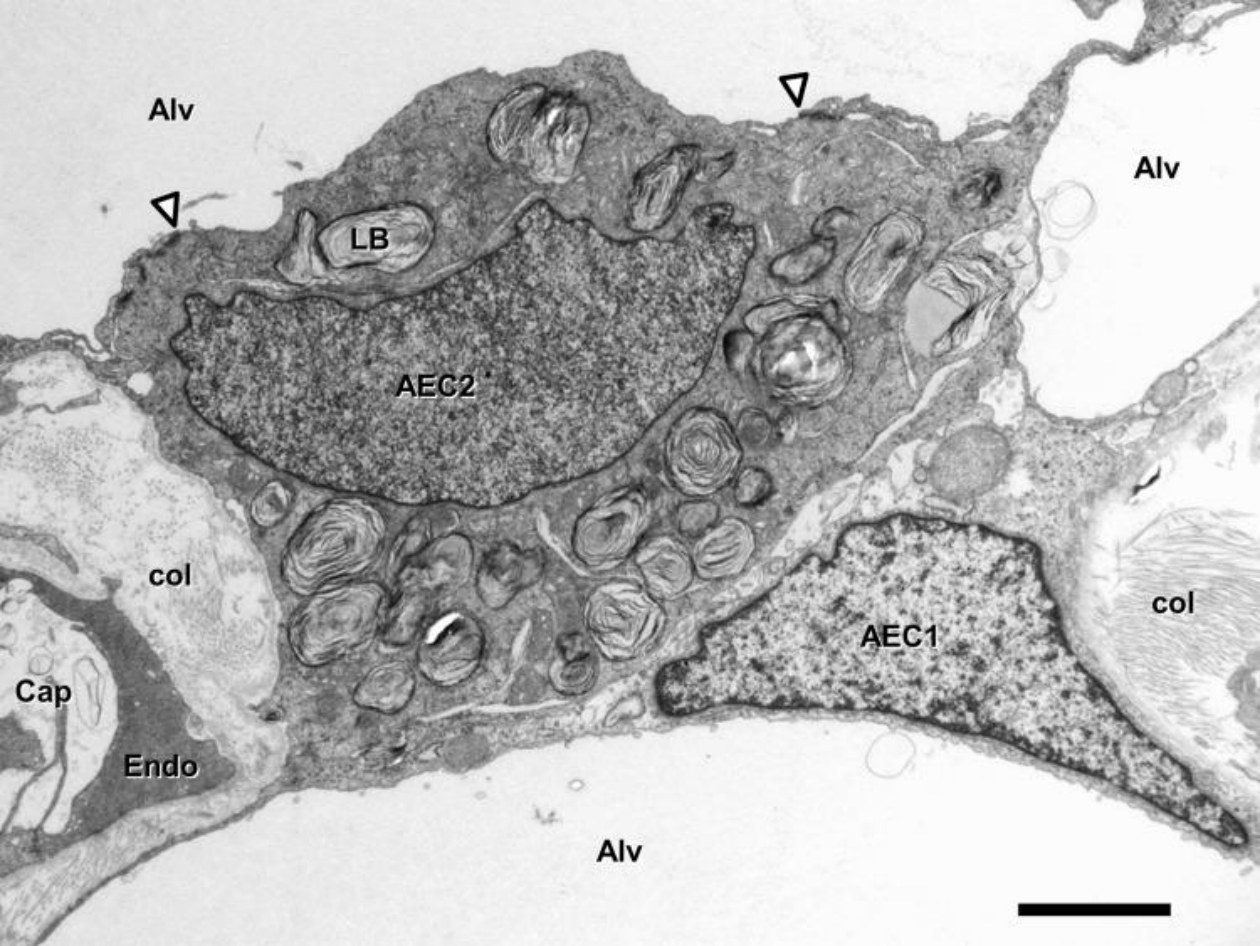

0.9999846 0.9999908804893494
0.9767964 2.384185791015625e-07
0.9054637 3.230571746826172e-05
0.8792378 0.00174027681350708
0.92751765 1.6689300537109375e-06


In [45]:
import pandas as pd

# df = pd.read_csv('/mnt/DATA/dorin/qualitytest/output_effnet_contrastive_v4/full_results_VuzRing/image_pairs_with_probs.csv')
df = pd.read_csv('/mnt/DATA/dorin/qualitytest/output_effnet_sim/full_results_PubMed/image_pairs_with_probs.csv')

for idx, row in df.iterrows():
    req_path = str(row["request_image_path"]).strip()
    src_path = str(row["source_image_path"]).strip()
    prob = float(row["match_probability"])
    
    req_img = Image.open(req_path)
    src_img = Image.open(src_path)

    req_ten = preprocess(req_img).unsqueeze(0)
    src_ten = preprocess(src_img).unsqueeze(0)
    similarities = model_(src_ten.to('cuda'), req_ten.to('cuda'), torch.tensor([[1]]).to('cuda'))
    if similarities.item() > 0.9:
        src_img.show()
        req_img.show()
    print(prob, similarities.item())

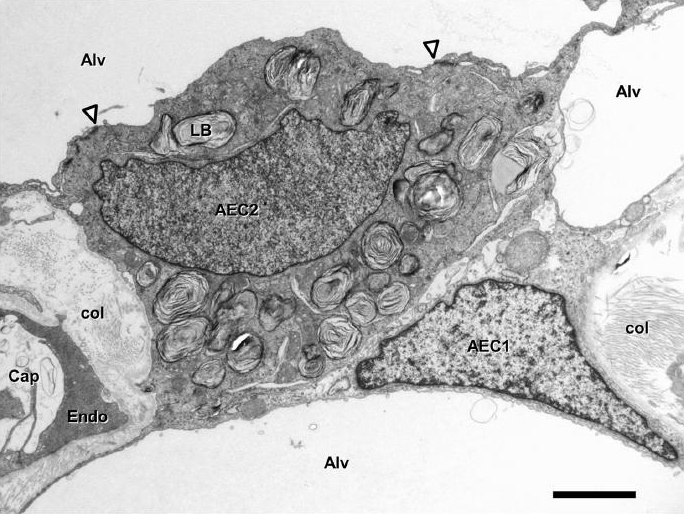

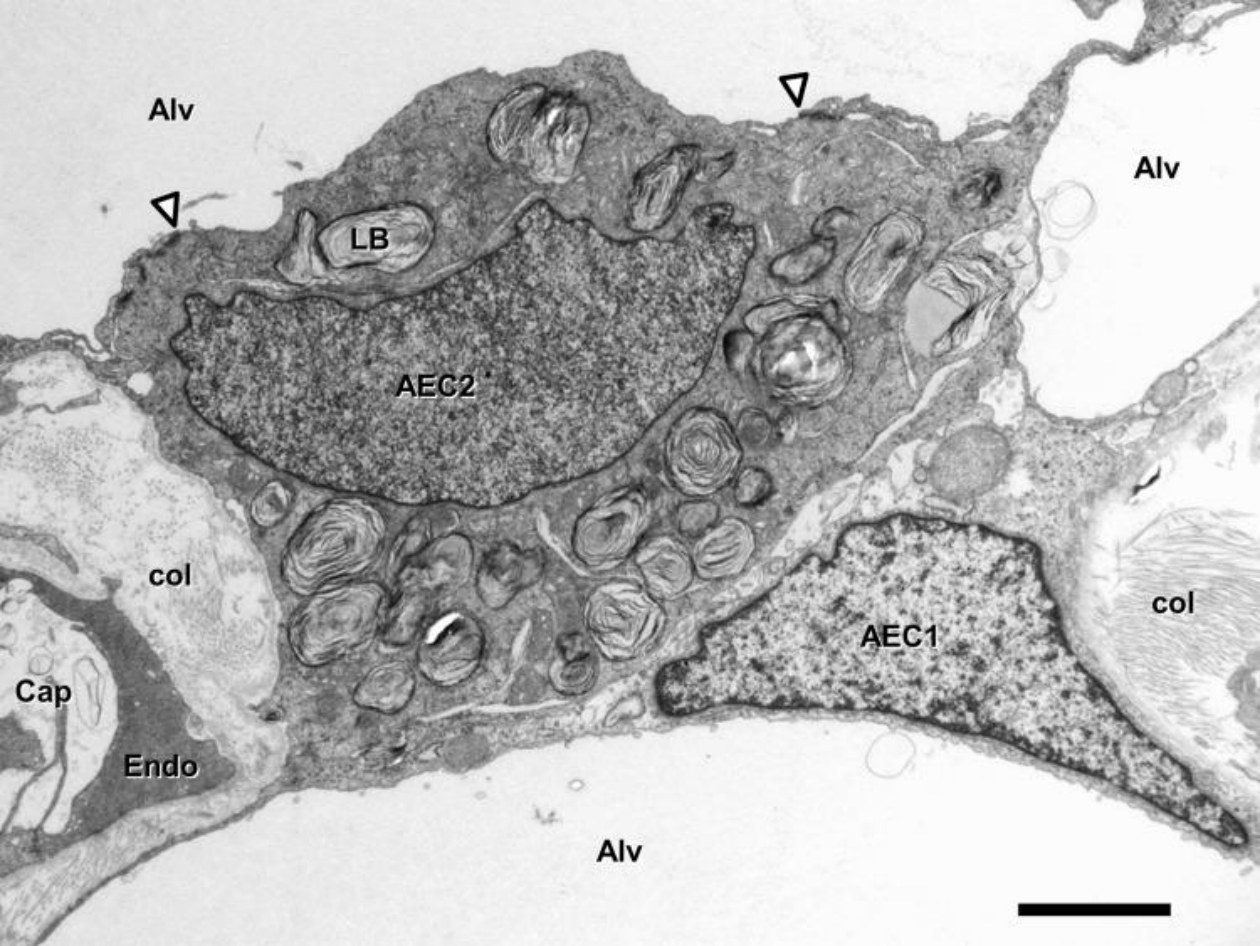

0.9999846 0.9999908804893494
0.9767964 2.384185791015625e-07
0.9054637 3.218650817871094e-05
0.8792378 0.0017403960227966309
0.92751765 1.6093254089355469e-06


In [44]:
import pandas as pd

# df = pd.read_csv('/mnt/DATA/dorin/qualitytest/output_effnet_contrastive_v4/full_results_VuzRing/image_pairs_with_probs.csv')
df = pd.read_csv('/mnt/DATA/dorin/qualitytest/output_effnet_sim/full_results_PubMed/image_pairs_with_probs.csv')

for idx, row in df.iterrows():
    req_path = str(row["request_image_path"]).strip()
    src_path = str(row["source_image_path"]).strip()
    prob = float(row["match_probability"])
    
    req_img = Image.open(req_path)
    src_img = Image.open(src_path)

    req_ten = preprocess(req_img).unsqueeze(0)
    src_ten = preprocess(src_img).unsqueeze(0)
    logits = model(src_ten.to('cuda'), req_ten.to('cuda'), torch.tensor([[1]]).to('cuda'))
    logits = logits[0][0]
    logits[:, model.pad_token_id] = -float('inf')
    logits[:, model.bos_token_id] = -float('inf')
    probs = torch.exp(logits) / torch.exp(logits).sum(dim=-1, keepdim=True)
    p_eos = probs[:, 2]
    similarities = 1.0 - p_eos
    if similarities.item() > 0.9:
        src_img.show()
        req_img.show()
    print(prob, similarities.item())
    # fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    # axes[0].imshow(req_img)
    # axes[0].set_title(f"Request\nMatch Prob: {prob:.4f}", fontsize=12, fontweight="bold")
    # axes[1].imshow(src_img)
    # axes[1].set_title("Source", fontsize=12, fontweight="bold")
    
    # axes[0].axis("off")
    # axes[1].axis("off")
    # plt.tight_layout()
    # plt.show()
    

In [9]:
from model_plagiarism_torch import (
    PlagiarismDetectionModelV2,
    ImageEncoder,
    ImageFuser,
    BinaryMatchHead,
    TransformationDecoder,
    preprocess,
)

import torch

# 1. Пути к чекпоинтам
encoder_path      = '/mnt/DATA2/dorin/weights/transformpredictor/effnet_updated/image_encoder.pth'
fuser_path        = '/mnt/DATA2/dorin/weights/transformpredictor/effnet_updated/fuser.pth'
match_head_path   = '/mnt/DATA2/dorin/weights/transformpredictor/effnet_updated/match_head.pth'
decoder_path      = '/mnt/DATA2/dorin/weights/transformpredictor/effnet_updated/decoder.pth'

# 2. Инициализация моделей (замените импорты на свои)
encoder  = ImageEncoder()
fuser    = ImageFuser()
head     = BinaryMatchHead()
decoder  = TransformationDecoder()

# 3. Определяем устройство
device = torch.device('cpu')

# 4. Универсальная функция загрузки
def load_model_weights(model, ckpt_path, device):
    # Загружаем файл на нужное устройство
    raw_ckpt = torch.load(ckpt_path, map_location=device)
    
    # Чекпоинты часто сохраняют не чистый state_dict, а словарь с ключами
    state_dict = raw_ckpt.get('state_dict') or raw_ckpt.get('model_state_dict') or raw_ckpt
    
    # Убираем префикс 'module.', если модель обучалась в DataParallel/Distributed
    if any(k.startswith('module.') for k in state_dict.keys()):
        state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
        
    model.load_state_dict(state_dict, strict=True)
    model.to(device)
    model.eval()  # Отключает Dropout / переводит BatchNorm в режим инференса
    return model

# 5. Загрузка всех моделей
encoder = load_model_weights(encoder, encoder_path, device)
fuser   = load_model_weights(fuser, fuser_path, device)
head    = load_model_weights(head, match_head_path, device)
decoder = load_model_weights(decoder, decoder_path, device)

In [10]:
pl_model = PlagiarismDetectionModelV2(device='cpu')

pl_model.load_components(
    encoder_path='/mnt/DATA2/dorin/weights/transformpredictor/effnet_updated/image_encoder.pth',
    fuser_path='/mnt/DATA2/dorin/weights/transformpredictor/effnet_updated/fuser.pth',
    match_head_path='/mnt/DATA2/dorin/weights/transformpredictor/effnet_updated/match_head.pth',
    decoder_path='/mnt/DATA2/dorin/weights/transformpredictor/effnet_updated/decoder.pth',
)

pl_model.device = 'cpu'
pl_model.eval()
print('ready')

ready


In [13]:
# pl_model(image_tensor_1, image_tensor_2).item()
pl_model.compute_similarities_batch([image_2], [[image_1]], mode='decoder')

[[5.960464477539063e-08]]

In [51]:
vector1 = encoder(image_tensor_1)
# vector2 = encoder(transformed_image_tensor)
vector2 = encoder(image_tensor_2)

In [52]:
fused = fuser(vector1, vector2)
logits = decoder(fused, torch.tensor([[1]]))

In [53]:
# logits = model(image_tensor_1, transformed_image_tensor, torch.tensor([[1]]))
logits[:, model.pad_token_id] = -float('inf')
logits[:, model.bos_token_id] = -float('inf')
probs = torch.exp(logits) / torch.exp(logits).sum(dim=-1, keepdim=True)
p_eos = probs[:, 2]
similarities = 1.0 - p_eos
similarities.item()

5.960464477539063e-08

In [ ]:
0.9999189376831055